## **Importing libraries**

In [1]:
!pip install roboflow
!pip install torchmetrics

In [2]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
import cv2
import os

In [3]:

from roboflow import Roboflow
rf = Roboflow(api_key="X6hxyswLEDTEMqXLaabt")
project = rf.workspace("mohamed-gomaa-myhdv").project("1-caucafall-nkqex-xh5oi")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 1️⃣-CAUCAFall-1 in yolov8:: 100%|██████████| 5300/5300 [00:00<00:00, 7719.39it/s]


## **Removing annotation file with size zero**

In [39]:
%cd /content/1️⃣-CAUCAFall-1/

/content/1️⃣-CAUCAFall-1


In [35]:

annotation_dirs = ["./train/labels", "./valid/labels"]
images_dirs = ["./train/images", "./valid/images"]

print(f'Before : {len(os.listdir(annotation_dirs[0]))}')
print(f'Before : {len(os.listdir(annotation_dirs[1]))}')

for annotation_dir, images_dir in zip(annotation_dirs, images_dirs):
    annotations = os.listdir(annotation_dir)
    images = set(os.listdir(images_dir))  # Use a set for faster lookup

    for annotation in annotations:
        annotation_file = os.path.join(annotation_dir, annotation)
        image_file_name = annotation[:-4] + '.jpg'

        # Delete annotation file if the corresponding image is missing
        if image_file_name not in images:
            os.remove(annotation_file)
            continue  # No need to check further

        with open (annotation_file,"r") as f:
            for line in f:
                data = line.strip().split()
                if len(data) < 5:
                    f.close()
                    os.remove(annotation_file)
                break

print(f'After : {len(os.listdir(annotation_dirs[0]))}')
print(f'After : {len(os.listdir(annotation_dirs[1]))}')

Before : 1595
Before : 533
After : 1595
After : 533


## **Create customdataset class**

In [36]:
class CustomDataset():
    def __init__(self, image_dir, annotations, annotations_dir, transform=None):
        self.image_dir = image_dir
        self.annotations = annotations
        self.annotations_dir = annotations_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        # Get annotation file name
        annotation = self.annotations[idx]
        # Get image path
        img_path = os.path.join(self.image_dir, annotation[:-4] + '.jpg')

        # Load image
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image {img_path} not found.")

        # Convert image channels
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Get image dimensions
        height, width, _ = image.shape

        # Parse the annotation file
        annotation_file = os.path.join(self.annotations_dir, annotation)
        boxes = []
        labels = []

        # Open annotation file
        with open(annotation_file, "r") as f:
            for line in f:
                # Split data
                data = line.strip().split()
                class_index = int(data[0])  # Class index
                x_center = float(data[1]) * width
                y_center = float(data[2]) * height
                box_width = float(data[3]) * width
                box_height = float(data[4]) * height

                # Convert to absolute coordinates [xmin, ymin, xmax, ymax]
                xmin = x_center - box_width / 2
                ymin = y_center - box_height / 2
                xmax = x_center + box_width / 2
                ymax = y_center + box_height / 2

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(int(class_index + 1))

        # Convert to PyTorch tensors
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Create target dictionary
        target = {"boxes": boxes, "labels": labels}

        return image, target



## **Load Pretrained Model and Modify for Custom Classes**

In [ ]:
num_classes = 3  # Number of classes (1 background + 2 custom classes)

## get the pretrained backbone model
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights="COCO_V1")
# 1. fasterrcnn_mobilenet_v3_large_320_fpn

print(model)

# # Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes)


for param in model.backbone.parameters():
    param.requires_grad = True


Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to /root/.cache/torch/hub/checkpoints/ssdlite320_mobilenet_v3_large_coco-a79551df.pth


100%|██████████| 13.4M/13.4M [00:00<00:00, 196MB/s]

SSD(
  (backbone): SSDLiteFeatureExtractorMobileNet(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (2): Hardswish()
        )
        (1): InvertedResidual(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
            )
            (1): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
          )
        )
        (2): Invert

AttributeError: 'SSD' object has no attribute 'roi_heads'

In [38]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

## **Creating the Dataloader**

In [40]:
# Step 4: Dataset and DataLoader
train_image_dir = "./train/images"
train_annotation_dir = "./train/labels"
train_annotations = os.listdir(train_annotation_dir)

train_dataset = CustomDataset(train_image_dir, train_annotations, train_annotation_dir, transform=transforms.ToTensor())

train_data_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [41]:
print(len(train_data_loader))

399


## **Setting LR OPTIM**

In [44]:
# Step 5: Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
num_epochs = 10


# Epoch 1, LR: 0.001000
# Epoch 2, LR: 0.001000
# Epoch 3, LR: 0.001000
# Epoch 4, LR: 0.001 * 0.1 ==   0.000100
# Epoch 5, LR: 0.000100
# Epoch 6, LR: 0.000100
# Epoch 7, LR: 0.0001 * 0.1 == 0.000010


print(device)

cuda


## **Checking Dataloader**

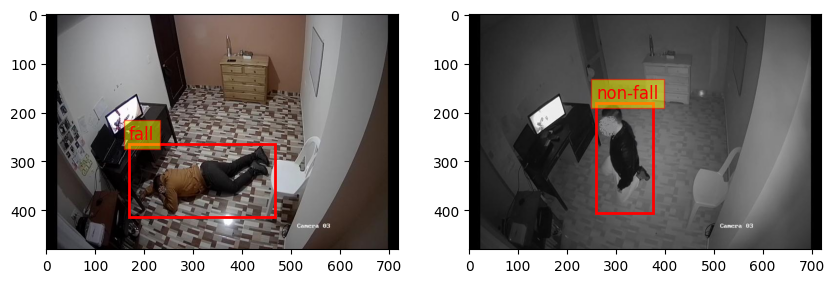

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create the plot
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.ravel()

# Get a batch of images and targets from the data loader
data_loader_iter = iter(train_data_loader)
images, targets = next(data_loader_iter)


class_names = ['bg', 'fall', 'non-fall']

# Plot the images with bounding boxes
for idx in range(2):
    image = images[idx].permute(1, 2, 0).numpy()  # Convert from (C, H, W) to (H, W, C) for visualization
    target = targets[idx]
    boxes = target["boxes"].numpy()
    labels = target["labels"].numpy()

    ax[idx].imshow(image)

    # Add bounding boxes to the image
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin
        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax[idx].add_patch(rect)
        ax[idx].text(
            xmin,
            ymin - 10,
            f"{class_names[label]}",
            color="red",
            fontsize=12,
            bbox=dict(facecolor="yellow", alpha=0.5, edgecolor="red"),
        )

# Display the image with bounding boxes
plt.show()

In [46]:
# Step 6: Training Loop

train_loss = []
val_loss = []

for epoch in range(num_epochs):

    print(f'Starting the trainig of Epoch_{epoch+1}.....')
    print('Training...')

    model.train()
    train_running_loss = 0

    print(f'Epoch {epoch+1}/{num_epochs} training')


    for images, targets in train_data_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())
        # loss_classifier → Measures how well the model classifies objects into correct categories.
        # loss_box_reg → Evaluates how accurately the predicted bounding boxes match the ground truth.
        # loss_objectness → Checks how confident the model is in detecting objects versus background.
        # loss_rpn_box_reg → Assesses how well the Region Proposal Network (RPN) refines anchor boxes to better fit objects.

        # Backward pass
        optimizer.zero_grad() ## converting gradient value to zero for per batch
        losses.backward() ## compute the gradient
        optimizer.step() ## update the weights

        train_running_loss += losses.item()

    scheduler.step()
    train_loss.append(train_running_loss)
    print(f"Train_Loss: {train_running_loss/len(train_dataset):.4f}")
    print('\n')

Starting the trainig of Epoch_1.....
Training...
Epoch 1/10 training
Train_Loss: 0.2162


Starting the trainig of Epoch_2.....
Training...
Epoch 2/10 training
Train_Loss: 0.1783


Starting the trainig of Epoch_3.....
Training...
Epoch 3/10 training
Train_Loss: 0.1603


Starting the trainig of Epoch_4.....
Training...
Epoch 4/10 training
Train_Loss: 0.1114


Starting the trainig of Epoch_5.....
Training...
Epoch 5/10 training
Train_Loss: 0.1007


Starting the trainig of Epoch_6.....
Training...
Epoch 6/10 training
Train_Loss: 0.0960


Starting the trainig of Epoch_7.....
Training...
Epoch 7/10 training
Train_Loss: 0.0875


Starting the trainig of Epoch_8.....
Training...
Epoch 8/10 training
Train_Loss: 0.0869


Starting the trainig of Epoch_9.....
Training...
Epoch 9/10 training
Train_Loss: 0.0865


Starting the trainig of Epoch_10.....
Training...
Epoch 10/10 training
Train_Loss: 0.0859




In [47]:
# Step 7: Save Trained Model
torch.save(model.state_dict(), "faster_rcnn_customv1.pth")

{'boxes': tensor([[241.7186, 222.4310, 395.3918, 401.2052]], device='cuda:0'), 'labels': tensor([2], device='cuda:0'), 'scores': tensor([0.9991], device='cuda:0')}
{'boxes': tensor([[279.6941, 171.1632, 435.9557, 356.4464]], device='cuda:0'), 'labels': tensor([2], device='cuda:0'), 'scores': tensor([0.9991], device='cuda:0')}
{'boxes': tensor([[258.3584, 228.4736, 514.9411, 346.5493]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9990], device='cuda:0')}
{'boxes': tensor([[277.1636, 213.4332, 407.3973, 459.0444]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9990], device='cuda:0')}
{'boxes': tensor([[259.9102, 198.0394, 374.7947, 386.1133]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9997], device='cuda:0')}
{'boxes': tensor([[289.2867, 216.5319, 434.4376, 444.3502]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9996], device='cuda:0')}
{'boxes': tensor

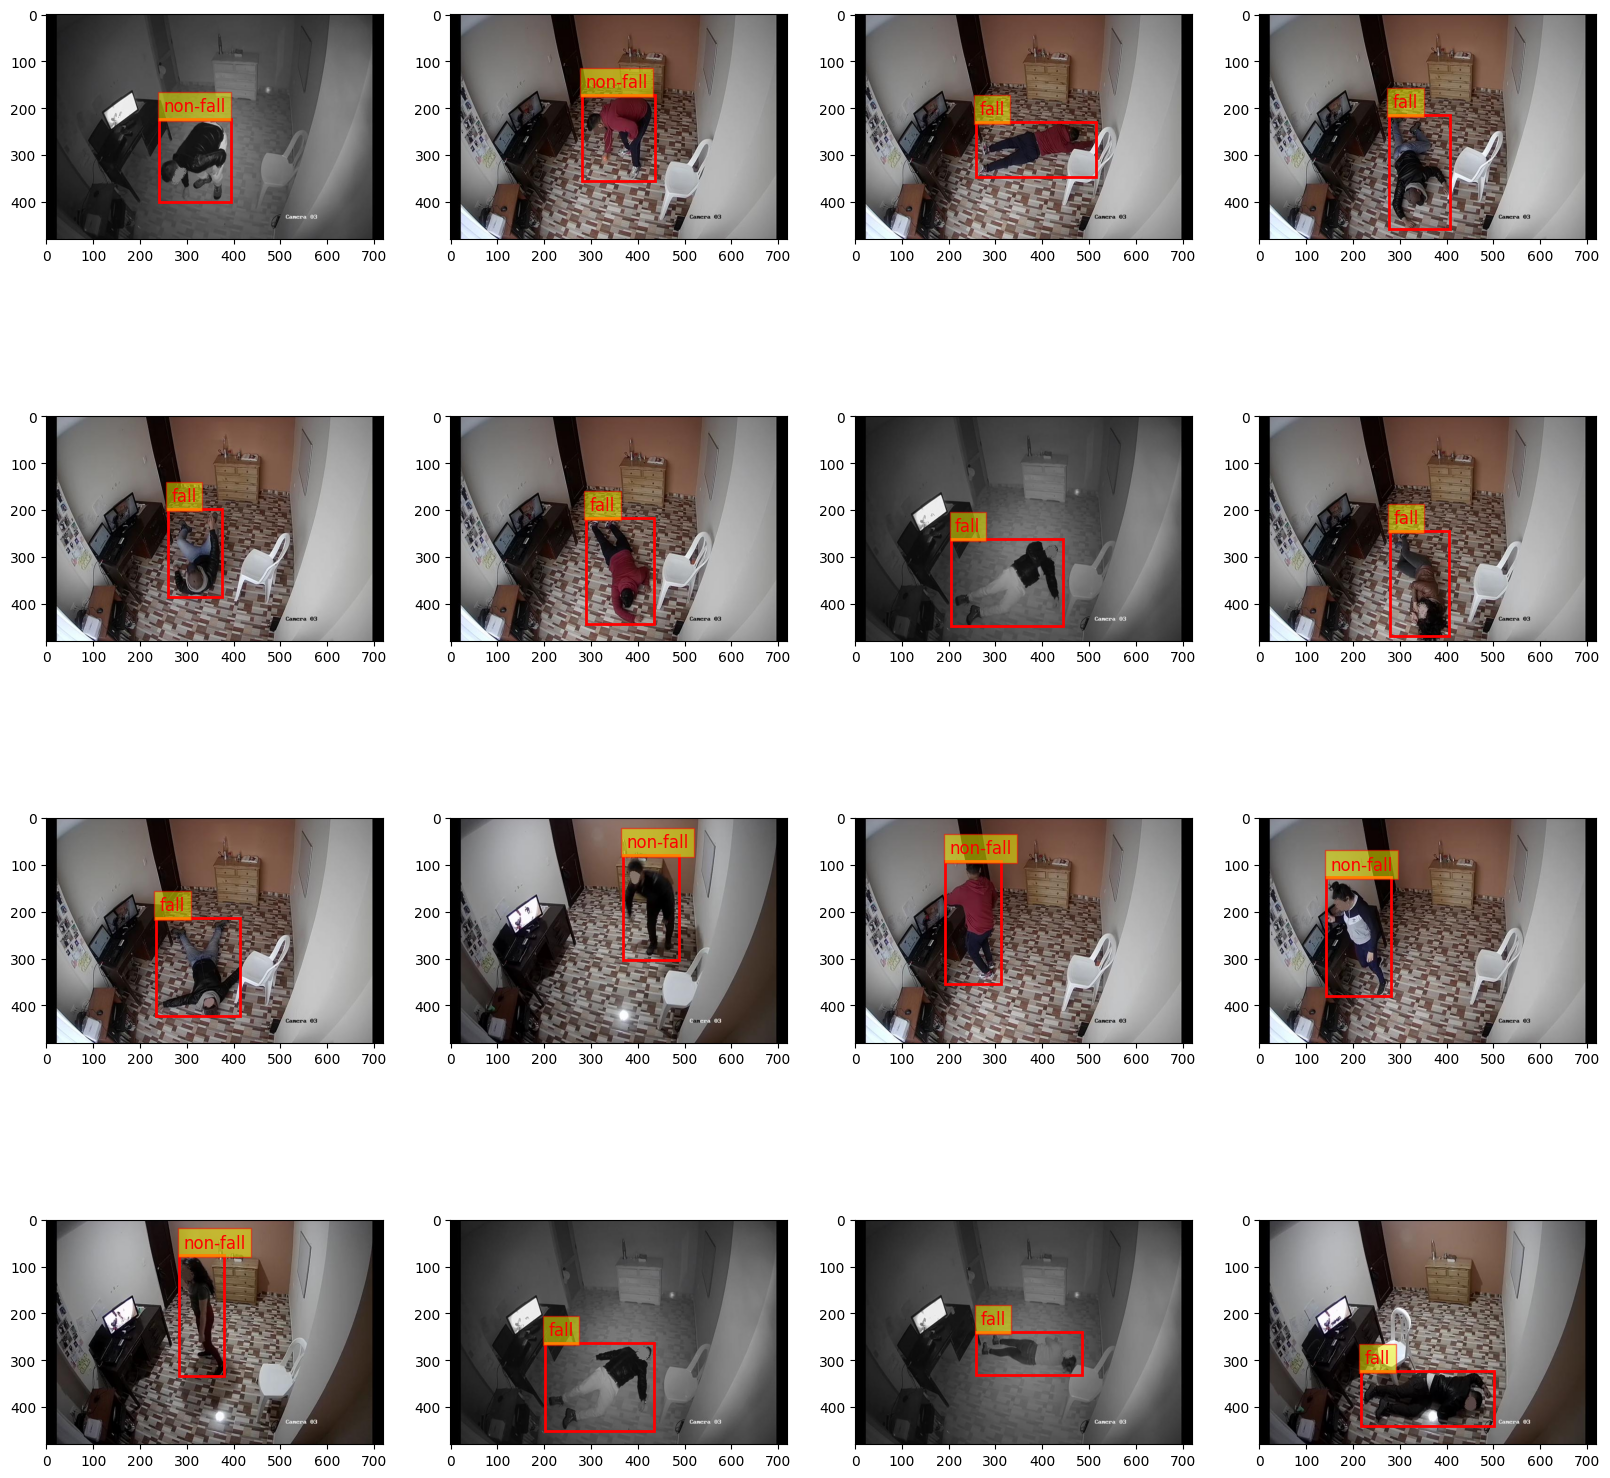

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image,ImageDraw
import random
import os
import torch
import torchvision
from torchvision.transforms import transforms


# Step 1: Recreate the model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Step 3: Load Pretrained Model and Modify for Custom Classes
num_classes = 3  # Number of classes (2 custom classes + 1 background)
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights="COCO_V1")
# Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)


model.load_state_dict(torch.load("./faster_rcnn_customv1.pth"))
# Assuming `model` and `test_data_loader` are already defined
model.eval()  # Set the model to evaluation mode
model.to(device)  # Ensure the model is on the correct device

# Create the plot
fig, ax = plt.subplots(4, 4, figsize=(20,20))
ax = ax.ravel()

transform = transforms.ToTensor()

test_dir = "./test/images"
test_list_file = os.listdir(test_dir)
# font = ImageFont.truetype("arial.ttf", 28)


class_names = ['bg', 'fall', 'non-fall']

for idx in range(16):
    # Prepare the image
    img_path = os.path.join(test_dir,random.choice(test_list_file))
    image = Image.open(img_path)
    image = transform(image)
    image_tensor = image.unsqueeze(0).to(device)  # Add a batch dimension

    # Get predictions
    with torch.no_grad():
        prediction = model(image_tensor)[0]  # Get the first image's predictions

    print(prediction)

    # Convert image to numpy for visualization
    image_np = image.cpu().permute(1, 2, 0).numpy()  # Convert (C, H, W) -> (H, W, C)

    # Extract predictions
    boxes = prediction["boxes"].cpu().numpy()
    labels = prediction["labels"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()

    ax[idx].imshow(image_np)

    img = Image.open(img_path)
    colors = [(255,0,0),(0,255,0),(0,0,255),(255,0,255),(255,255,0),(0,255,255),(255,140,0),(0,128,0)]

    # Add bounding boxes to the image
    for box, label, score in zip(boxes, labels, scores):
        if score >= 0.8:
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            rect = patches.Rectangle(
                (xmin,
                ymin),
                width,
                height,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax[idx].add_patch(rect)
            ax[idx].text(
                xmin + 8,
                ymin - 16,
                f"{class_names[label]}",
                color="red",
                fontsize=12,
                bbox=dict(facecolor="yellow", alpha=0.5, edgecolor="red"),
            )
            color = random.choice(colors)
            img1 = ImageDraw.Draw(img)
            img1.rectangle([(int(xmin),int(ymin)),(int(xmax),int(ymax))],outline=color,width=4)
            img1.text((int(xmin),int(ymin-30)), "Bear", fill=color)
            # img.save(f'img/image_{idx}.png')


# Display the image with bounding boxes
plt.show()

In [53]:
import numpy as np
from sklearn.metrics import classification_report
import torchvision.ops as ops

## Prepare for Evaluation


## **Generating Classification Report for Labels**

In [51]:
# Step 4: Dataset and DataLoader
test_image_dir = "./test/images"
test_annotation_dir = "./test/labels"
test_annotations = os.listdir(test_annotation_dir)

test_dataset = CustomDataset(test_image_dir, test_annotations, test_annotation_dir, transform=transforms.ToTensor())

test_data_loader = DataLoader(test_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [55]:
model.eval()  # Set the model to evaluation mode
model.to(device)  # Ensure the model is on the correct device

# Initialize lists to store true and predicted labels for classification report
true_labels_matched = []
predicted_labels_matched = []

# Initialize lists to store all predictions and ground truths for mAP calculation
all_predictions = []
all_ground_truths = []

# Define confidence and IoU thresholds
confidence_threshold = 0.5
iou_threshold = 0.5

print("Model set to evaluation mode and moved to device.")
print("Evaluation lists and thresholds initialized.")

Model set to evaluation mode and moved to device.
Evaluation lists and thresholds initialized.


**Reasoning**:
The next step is to iterate through the test dataset, perform inference, filter predictions, match them to ground truth bounding boxes using IoU, and collect the matched true and predicted labels for the classification report, as well as all predictions and ground truths for mAP calculation.



**Reasoning**:
The previous code failed because `true_boxes` was on the CPU and `pred_boxes_filtered` was on the GPU, leading to a `RuntimeError` during `ops.box_iou` calculation. I will modify the code to ensure `true_boxes` are also moved to the device (CUDA) before calculating IoU to resolve this device mismatch.



In [57]:
for images, targets in test_data_loader:
    images = list(image.to(device) for image in images)
    # Move targets to the same device as the model for IoU calculation
    targets_on_device = [{k: v.to(device) for k, v in t.items()} for t in targets]

    with torch.no_grad():
        predictions = model(images)

    for i, prediction in enumerate(predictions):
        true_boxes = targets_on_device[i]["boxes"]
        true_labels = targets_on_device[i]["labels"]

        pred_boxes = prediction["boxes"]
        pred_labels = prediction["labels"]
        pred_scores = prediction["scores"]

        # Filter predictions by confidence threshold
        high_confidence_indices = torch.where(pred_scores >= confidence_threshold)[0]
        pred_boxes_filtered = pred_boxes[high_confidence_indices]
        pred_labels_filtered = pred_labels[high_confidence_indices]
        pred_scores_filtered = pred_scores[high_confidence_indices]

        # Prepare predictions for mAP calculation (add image_id to match expected format)
        # For each image, create a dictionary of predictions
        if len(pred_boxes_filtered) > 0:
            all_predictions.append({
                "boxes": pred_boxes_filtered.cpu().numpy(),
                "labels": pred_labels_filtered.cpu().numpy(),
                "scores": pred_scores_filtered.cpu().numpy(),
            })
        else:
            all_predictions.append({
                "boxes": np.array([]).reshape(0,4),
                "labels": np.array([]),
                "scores": np.array([]),
            })

        # Prepare ground truths for mAP calculation
        if len(true_boxes) > 0:
            all_ground_truths.append({
                "boxes": true_boxes.cpu().numpy(),
                "labels": true_labels.cpu().numpy(),
            })
        else:
            all_ground_truths.append({
                "boxes": np.array([]).reshape(0,4),
                "labels": np.array([]),
            })


        # Matching predictions to ground truths for classification report
        if len(true_boxes) > 0 and len(pred_boxes_filtered) > 0:
            iou_matrix = ops.box_iou(true_boxes, pred_boxes_filtered)
            # Find the best matching prediction for each true box
            # For each true box, find the predicted box with highest IoU
            matched_preds = torch.max(iou_matrix, dim=1)

            # Iterate through true boxes to find matches based on IoU threshold
            for true_box_idx, (max_iou, pred_box_idx) in enumerate(zip(matched_preds.values, matched_preds.indices)):
                if max_iou >= iou_threshold:
                    true_labels_matched.append(true_labels[true_box_idx].item())
                    predicted_labels_matched.append(pred_labels_filtered[pred_box_idx].item())
                else:
                    # If a true box is not matched, it's a false negative (unmatched true label)
                    # We will handle false negatives and false positives globally for classification_report
                    # For now, just collect matched labels
                    pass # Not appending for unmatched true boxes for direct report

        elif len(true_boxes) > 0 and len(pred_boxes_filtered) == 0:
            # No predictions, all true boxes are false negatives
            # No matched labels to append for classification_report based on current approach
            pass
        elif len(true_boxes) == 0 and len(pred_boxes_filtered) > 0:
            # No true boxes, all predictions are false positives
            # No matched labels to append for classification_report based on current approach
            pass

print("Finished iterating through the test dataset and collecting predictions and ground truths.")
print(f"Collected {len(true_labels_matched)} matched true labels and {len(predicted_labels_matched)} matched predicted labels.")
print(f"Collected {len(all_predictions)} prediction sets and {len(all_ground_truths)} ground truth sets for mAP calculation.")

Finished iterating through the test dataset and collecting predictions and ground truths.
Collected 516 matched true labels and 516 matched predicted labels.
Collected 517 prediction sets and 517 ground truth sets for mAP calculation.


**Reasoning**:
The previous step successfully collected the necessary true and predicted labels. Now, I will generate and print a classification report using `sklearn.metrics.classification_report` to evaluate the model's performance on label classification.



In [58]:
target_names = ['fall', 'non-fall']
true_labels_mapped = [label - 1 for label in true_labels_matched if label > 0]
predicted_labels_mapped = [label - 1 for label in predicted_labels_matched if label > 0]

if len(true_labels_mapped) > 0 and len(predicted_labels_mapped) > 0:
    report = classification_report(
        true_labels_mapped,
        predicted_labels_mapped,
        target_names=target_names,
        zero_division=0
    )
    print("\nClassification Report for Matched Detections:")
    print(report)
else:
    print("Not enough matched labels to generate a classification report.")



Classification Report for Matched Detections:
              precision    recall  f1-score   support

        fall       0.99      1.00      0.99       241
    non-fall       1.00      0.99      0.99       275

    accuracy                           0.99       516
   macro avg       0.99      0.99      0.99       516
weighted avg       0.99      0.99      0.99       516



In [62]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Initialize mAP metric
metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", iou_thresholds=[0.5])

# Convert collected predictions and ground truths to the format expected by torchmetrics
maps_predictions = []
maps_ground_truths = []

for i in range(len(all_predictions)):
    maps_predictions.append({
        "boxes": torch.tensor(all_predictions[i]["boxes"]), # Ensure tensor type
        "labels": torch.tensor(all_predictions[i]["labels"]), # Ensure tensor type
        "scores": torch.tensor(all_predictions[i]["scores"])
    })
    maps_ground_truths.append({
        "boxes": torch.tensor(all_ground_truths[i]["boxes"]),
        "labels": torch.tensor(all_ground_truths[i]["labels"])
    })

# Update metric with predictions and ground truths
metric.update(maps_predictions, maps_ground_truths)

# Compute mAP
maps = metric.compute()

print(f"\nmAP@0.5: {maps['map_50']:.4f}")


mAP@0.5: 0.9900


## Calculate Inference Time

Measure the time taken for the model to perform inference on each image in the test set and calculate the average inference time per image.


In [63]:
import time

# Initialize an empty list to store inference times
inference_times = []

# Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print("Calculating inference time...")

for i, (images, targets) in enumerate(test_data_loader):
    # Record the start time before inference
    start_time = time.time()

    # Move images to the device
    images = list(image.to(device) for image in images)

    # Perform a forward pass
    with torch.no_grad():
        predictions = model(images)

    # Record the end time after inference
    end_time = time.time()

    # Calculate inference time for the current batch (and append per image)
    batch_inference_time = end_time - start_time
    # Assuming batch_size is 4 as defined for test_data_loader
    num_images_in_batch = len(images)
    for _ in range(num_images_in_batch):
        inference_times.append(batch_inference_time / num_images_in_batch)

# Calculate the average inference time
if inference_times:
    average_inference_time = sum(inference_times) / len(inference_times)
    print(f"Average inference time per image: {average_inference_time:.6f} seconds")
else:
    print("No images processed to calculate inference time.")


Calculating inference time...
Average inference time per image: 0.007174 seconds
